<a href="https://colab.research.google.com/github/amanrajgibs/Manufacturing-Process-Improvement-Productivity-Optimization/blob/main/Productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("garments_worker_productivity.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1197, 15)
       date   quarter  department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1      sweing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing   Thursday     1                   0.75   
2  1/1/2015  Quarter1      sweing  Thursday    11                   0.80   
3  1/1/2015  Quarter1      sweing  Thursday    12                   0.80   
4  1/1/2015  Quarter1      sweing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  
0                   0           59.0             0.940725  
1                 

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nCleaning Complete")


Missing Values:
date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

Cleaning Complete


In [6]:
df['productivity_gap'] = (
    df['targeted_productivity']
    - df['actual_productivity']
)

df['achievement_percent'] = (
    df['actual_productivity']
    / df['targeted_productivity']
) * 100

In [8]:
print("\n===== KPI SUMMARY =====")

print(
    "Average Productivity:",
    round(df['actual_productivity'].mean(),3)
)

print(
    "Average Target Productivity:",
    round(df['targeted_productivity'].mean(),3)
)

print(
    "Average Idle Time:",
    round(df['idle_time'].mean(),2)
)

print(
    "Average Overtime:",
    round(df['over_time'].mean(),2)
)


===== KPI SUMMARY =====
Average Productivity: 0.735
Average Target Productivity: 0.73
Average Idle Time: 0.73
Average Overtime: 4567.46



Department Performance
department
sweing        0.722013
finishing     0.722876
finishing     0.782089
Name: actual_productivity, dtype: float64


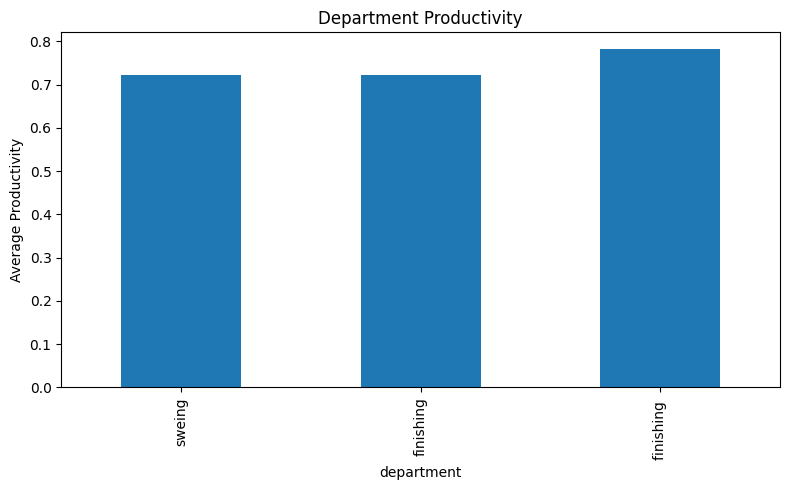

In [9]:
dept_analysis = df.groupby(
    'department'
)['actual_productivity'].mean().sort_values()

print("\nDepartment Performance")
print(dept_analysis)

plt.figure(figsize=(8,5))
dept_analysis.plot(kind='bar')
plt.title("Department Productivity")
plt.ylabel("Average Productivity")
plt.tight_layout()
plt.show()



Team Performance
team
7     0.668006
8     0.674148
11    0.681985
6     0.685385
5     0.697981
10    0.719736
9     0.734462
4     0.770035
2     0.770855
12    0.779055
3     0.803880
1     0.821054
Name: actual_productivity, dtype: float64


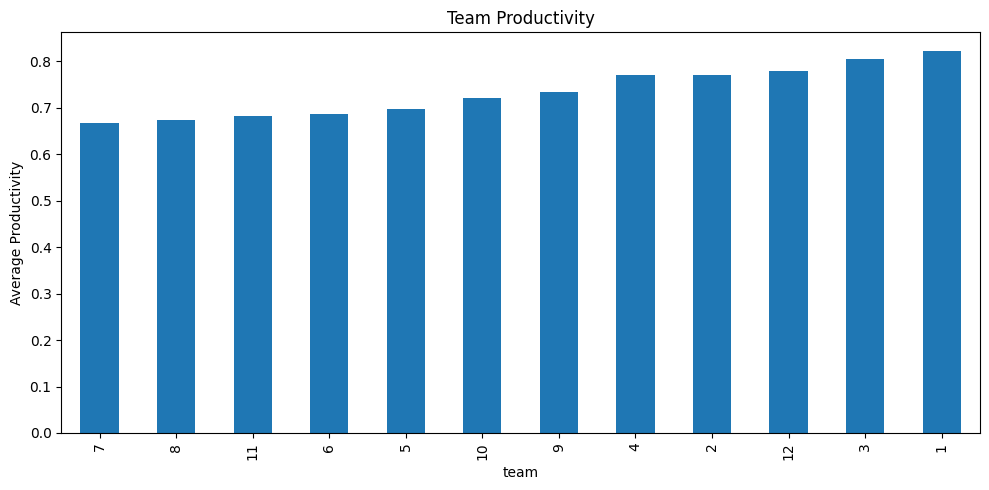

In [10]:
team_analysis = df.groupby(
    'team'
)['actual_productivity'].mean().sort_values()

print("\nTeam Performance")
print(team_analysis)

plt.figure(figsize=(10,5))
team_analysis.plot(kind='bar')
plt.title("Team Productivity")
plt.ylabel("Average Productivity")
plt.tight_layout()
plt.show()


Correlation Matrix
                       actual_productivity  targeted_productivity  idle_time  \
actual_productivity               1.000000               0.421594  -0.080851   
targeted_productivity             0.421594               1.000000  -0.056181   
idle_time                        -0.080851              -0.056181   1.000000   
over_time                        -0.054206              -0.088557   0.031038   
no_of_workers                    -0.057991              -0.084288   0.058049   

                       over_time  no_of_workers  
actual_productivity    -0.054206      -0.057991  
targeted_productivity  -0.088557      -0.084288  
idle_time               0.031038       0.058049  
over_time               1.000000       0.734164  
no_of_workers           0.734164       1.000000  


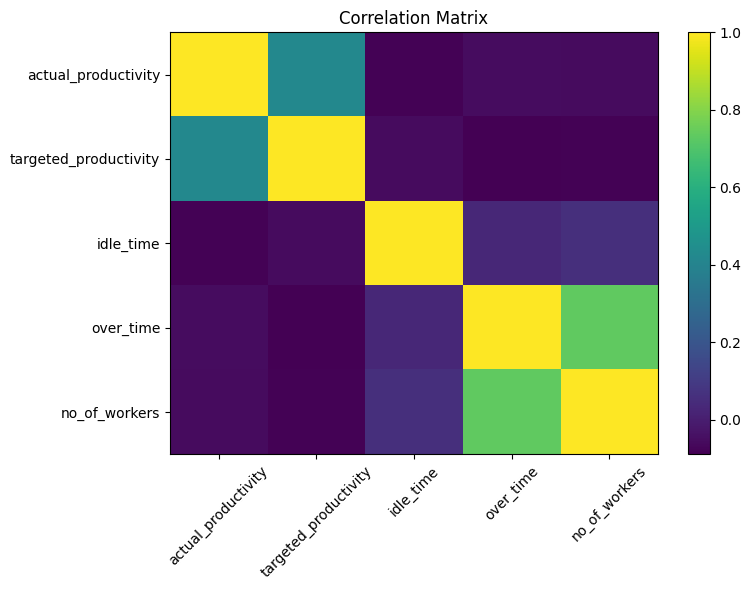

In [11]:
corr_cols = [
    'actual_productivity',
    'targeted_productivity',
    'idle_time',
    'over_time',
    'no_of_workers'
]

corr = df[corr_cols].corr()

print("\nCorrelation Matrix")
print(corr)

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


Pareto Table
               Cause     Impact  Cum_Percent
1          Over Time  5467250.0    99.228964
3  Worker Allocation    41428.0    99.980870
0          Idle Time      874.0    99.996733
2       Style Change      180.0   100.000000


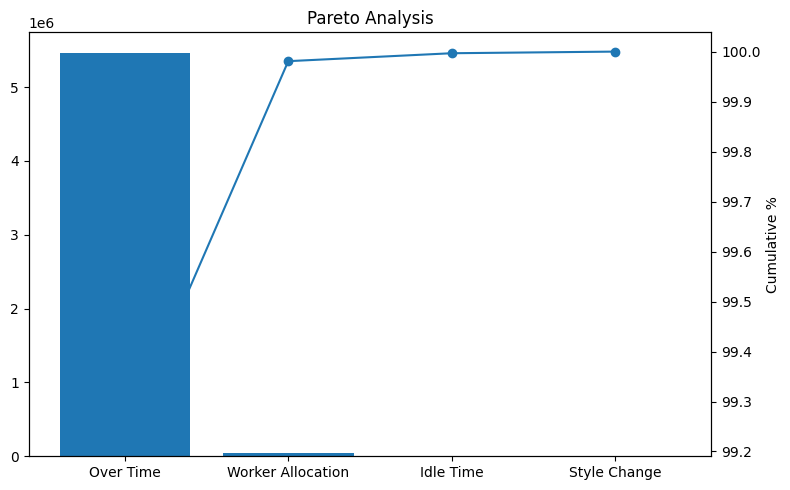

In [12]:
pareto_data = pd.DataFrame({
    'Cause':[
        'Idle Time',
        'Over Time',
        'Style Change',
        'Worker Allocation'
    ],
    'Impact':[
        df['idle_time'].sum(),
        df['over_time'].sum(),
        df['no_of_style_change'].sum(),
        df['no_of_workers'].sum()
    ]
})

pareto_data = pareto_data.sort_values(
    by='Impact',
    ascending=False
)
pareto_data['Cum_Percent'] = (
    pareto_data['Impact'].cumsum()
    / pareto_data['Impact'].sum()
) * 100

print("\nPareto Table")
print(pareto_data)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(
    pareto_data['Cause'],
    pareto_data['Impact']
)

ax2 = ax1.twinx()

ax2.plot(
    pareto_data['Cause'],
    pareto_data['Cum_Percent'],
    marker='o'
)

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis")
plt.tight_layout()
plt.show()

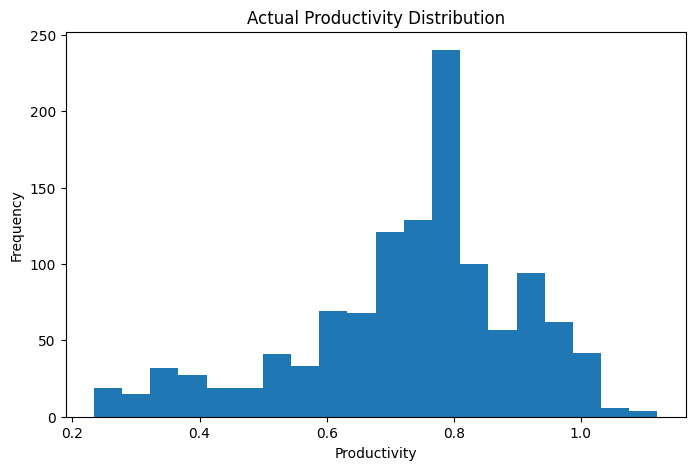

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df['actual_productivity'],
    bins=20
)

plt.title("Actual Productivity Distribution")
plt.xlabel("Productivity")
plt.ylabel("Frequency")

plt.show()


In [14]:
best_team = team_analysis.idxmax()
worst_team = team_analysis.idxmin()

print("\nBest Team:", best_team)
print("Worst Team:", worst_team)



Best Team: 1
Worst Team: 7


In [15]:
print("\n===== IMPROVEMENT RECOMMENDATIONS =====")

if df['idle_time'].mean() > 10:
    print(
        "- High idle time detected. Improve scheduling."
    )

if df['over_time'].mean() > 5000:
    print(
        "- Excess overtime observed. Rebalance workforce."
    )

print(
    "- Focus training on low-performing teams."
)

print(
    "- Reduce style change frequency through batch planning."
)

print(
    "- Monitor productivity achievement using KPI dashboard."
)


===== IMPROVEMENT RECOMMENDATIONS =====
- Focus training on low-performing teams.
- Reduce style change frequency through batch planning.
- Monitor productivity achievement using KPI dashboard.


In [16]:
dept_analysis.to_csv(
    "department_productivity.csv"
)

team_analysis.to_csv(
    "team_productivity.csv"
)

df.to_csv(
    "processed_productivity_data.csv",
    index=False
)

print(
    "\nAnalysis Complete. Files exported successfully."
)


Analysis Complete. Files exported successfully.
